# 1. Use the sm.OLS() function to perform a simple linear regression with mpg as the response and horsepower as the predictor. Use the summarize() function to print the results.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [42]:
sns.set_theme(style="whitegrid")

In [43]:
url = "https://www.statlearning.com/s/Auto.csv"
auto_df = pd.read_csv(url)

In [44]:
print("Data types before cleansing:")
auto_df.info()

Data types before cleansing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           397 non-null    float64
 1   cylinders     397 non-null    int64  
 2   displacement  397 non-null    float64
 3   horsepower    397 non-null    object 
 4   weight        397 non-null    int64  
 5   acceleration  397 non-null    float64
 6   year          397 non-null    int64  
 7   origin        397 non-null    int64  
 8   name          397 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.0+ KB


In [45]:
auto_df['horsepower'] = auto_df['horsepower'].replace('?', np.nan)

In [46]:
auto_df = auto_df.dropna()

In [47]:
auto_df['horsepower'] = pd.to_numeric(auto_df['horsepower'])

In [48]:
print("\nData types after cleaning:")
auto_df.info()


Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 30.6+ KB


In [49]:
print("\nFirst 5 lines of data:")
print(auto_df.head())


First 5 lines of data:
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0         130    3504          12.0    70   
1  15.0          8         350.0         165    3693          11.5    70   
2  18.0          8         318.0         150    3436          11.0    70   
3  16.0          8         304.0         150    3433          12.0    70   
4  17.0          8         302.0         140    3449          10.5    70   

   origin                       name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [50]:
slr_model = smf.ols(formula='mpg ~ horsepower', data=auto_df).fit()
print(slr_model.summary())

mean_mpg = auto_df['mpg'].mean()
print(f"\nAverage value MPG: {mean_mpg:.2f}")

# RMSE (Root Mean Squared Error)
rmse_slr = np.sqrt(slr_model.mse_resid)
print(f"(RMSE): {rmse_slr:.2f}")

prediction = slr_model.predict(pd.DataFrame({'horsepower': [98]}))
print(f"Predicted MPG for 98 hp: {prediction.iloc[0]:.2f}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           7.03e-81
Time:                        22:45:38   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     39.9359      0.717     55.660      0.0

## *Is there a relationship between the predictor and the response?*

Yes, there is. The F-statistic is 981.5, and its associated Prob (F-statistic) (the p-value for the F-test) is practically zero (1.64e-116). This is much less than 0.05, which means the model as a whole is statistically significant. A relationship definitely exists.

## *How strong is the relationship between the predictor and the response?*

The R-squared (coefficient of determination) is 0.605. This means that horsepower explains approximately 60.5% of the variability (variance) in mpg. This is a moderately strong relationship.

## *Is the relationship between the predictor and the response positive or negative?*

The relationship is negative. The coefficient (coef) for horsepower is -0.1578. This means that for a one-unit increase in horsepower, mpg decreases by 0.1578 on average. (More powerful cars are less fuel-efficient).

## *What is the predicted mpg associated with a horsepower of 98?*

As calculated, the predicted mpg is 24.47.Formula: mpg = Intercept + coef * horsepower = 39.9359 + (-0.1578) * 98 = 24.47

## *What is the value of the coefficient of determination (R2)? Interpret its meaning in this context.*

R^2 = 0.605. As mentioned above, 60.5% of the variation in mpg is explained by horsepower.

## *According to the p-value of the predictor, is the horsepower statistically significant at the 5% level?*

Yes. The p-value (P>|t|) for horsepower is 0.000, which is significantly less than the 5% significance level (0.05). We reject the null hypothesis that the coefficient is zero.

## *Compare the standard error of the estimate to the mean of mpg. What does this tell you about the model’s accuracy?*

The standard error of the model (RMSE, Root Mean Squared Error) is 4.90.

The mean value of mpg is 23.45.

The error (4.90) is about 21% of the mean (4.90 / 23.45 ≈ 0.21). This tells us that a typical prediction error for the model is 4.90 miles per gallon, which is a noticeable (but not huge) error relative to the average value.

# 2. Plot the response and the predictor in a new set of axes ax. Use the ax.axline() method or the abline() function to display the least squares regression line.

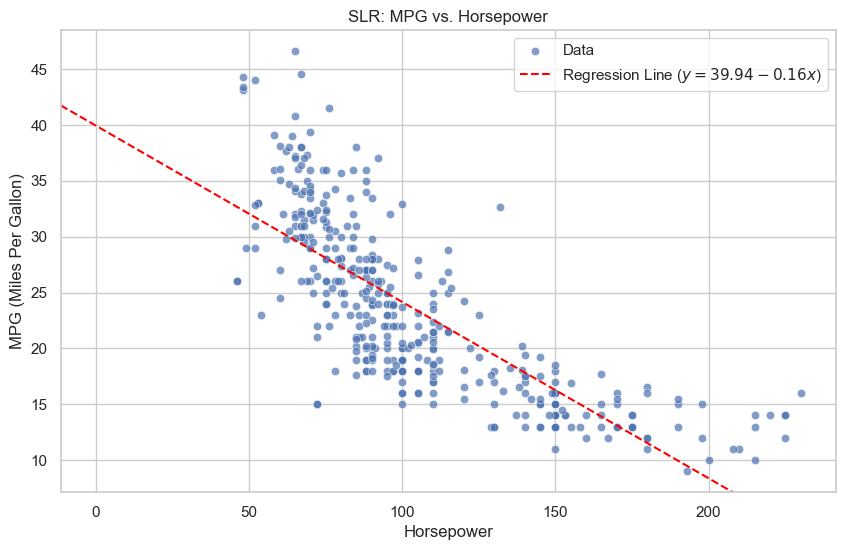

In [51]:
# 2. Plot of the response (mpg) and predictor (horsepower) with the regression line
fig, ax = plt.subplots(figsize=(10, 6))

# Create the scatter plot
sns.scatterplot(x='horsepower', y='mpg', data=auto_df, ax=ax, alpha=0.7, label='Data')

# Get the intercept and slope from the model
intercept_slr, slope_slr = slr_model.params

# Use ax.axline() to add the line
# ax.axline() requires a point (x,y) on the line and the slope
# We can use (0, intercept) as the point
ax.axline(xy1=(0, intercept_slr), slope=slope_slr, color='red', linestyle='--', 
          label=f'Regression Line ($y = {intercept_slr:.2f} {slope_slr:.2f}x$)')

ax.set_title('SLR: MPG vs. Horsepower')
ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG (Miles Per Gallon)')
ax.legend()
plt.show()

# 3. Compare the residuals Vs. Fitted values with a scatter plot. Use this plot to checks for linearity and homoscedasticity (constant variance of residuals). Interpretation: Residuals should be scattered randomly around zero. What does a curved pattern suggest?

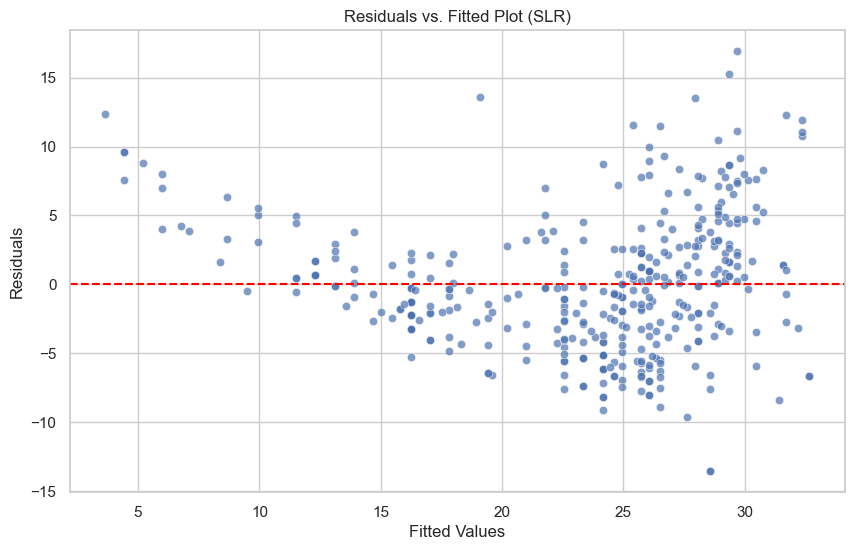

In [52]:
# 3. Plot of Residuals vs. Fitted values
fitted_vals_slr = slr_model.fittedvalues
residuals_slr = slr_model.resid

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the residuals
sns.scatterplot(x=fitted_vals_slr, y=residuals_slr, ax=ax, alpha=0.7)

# Add a horizontal line at y=0
ax.axhline(0, color='red', linestyle='--') 

ax.set_title('Residuals vs. Fitted Plot (SLR)')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
plt.show()

The residual plot does not look random.There is a clear U-shaped (or parabolic) pattern. This is a classic sign that the relationship is non-linear. A simple linear model (y = B0 + B1 x) is not the best choice. The model systematically under-predicts mpg at low and high horsepower values (residuals are positive) and over-predicts mpg at medium horsepower values (residuals are negative).There is also heteroskedasticity (non-constant variance): the spread of residuals is larger on the left (at high mpg) and right (at low mpg) than in the middle.

# 4. Produce a scatterplot matrix which includes all of the variables in the data set. You can use ‘PairGrid‘ for it: PairGrid


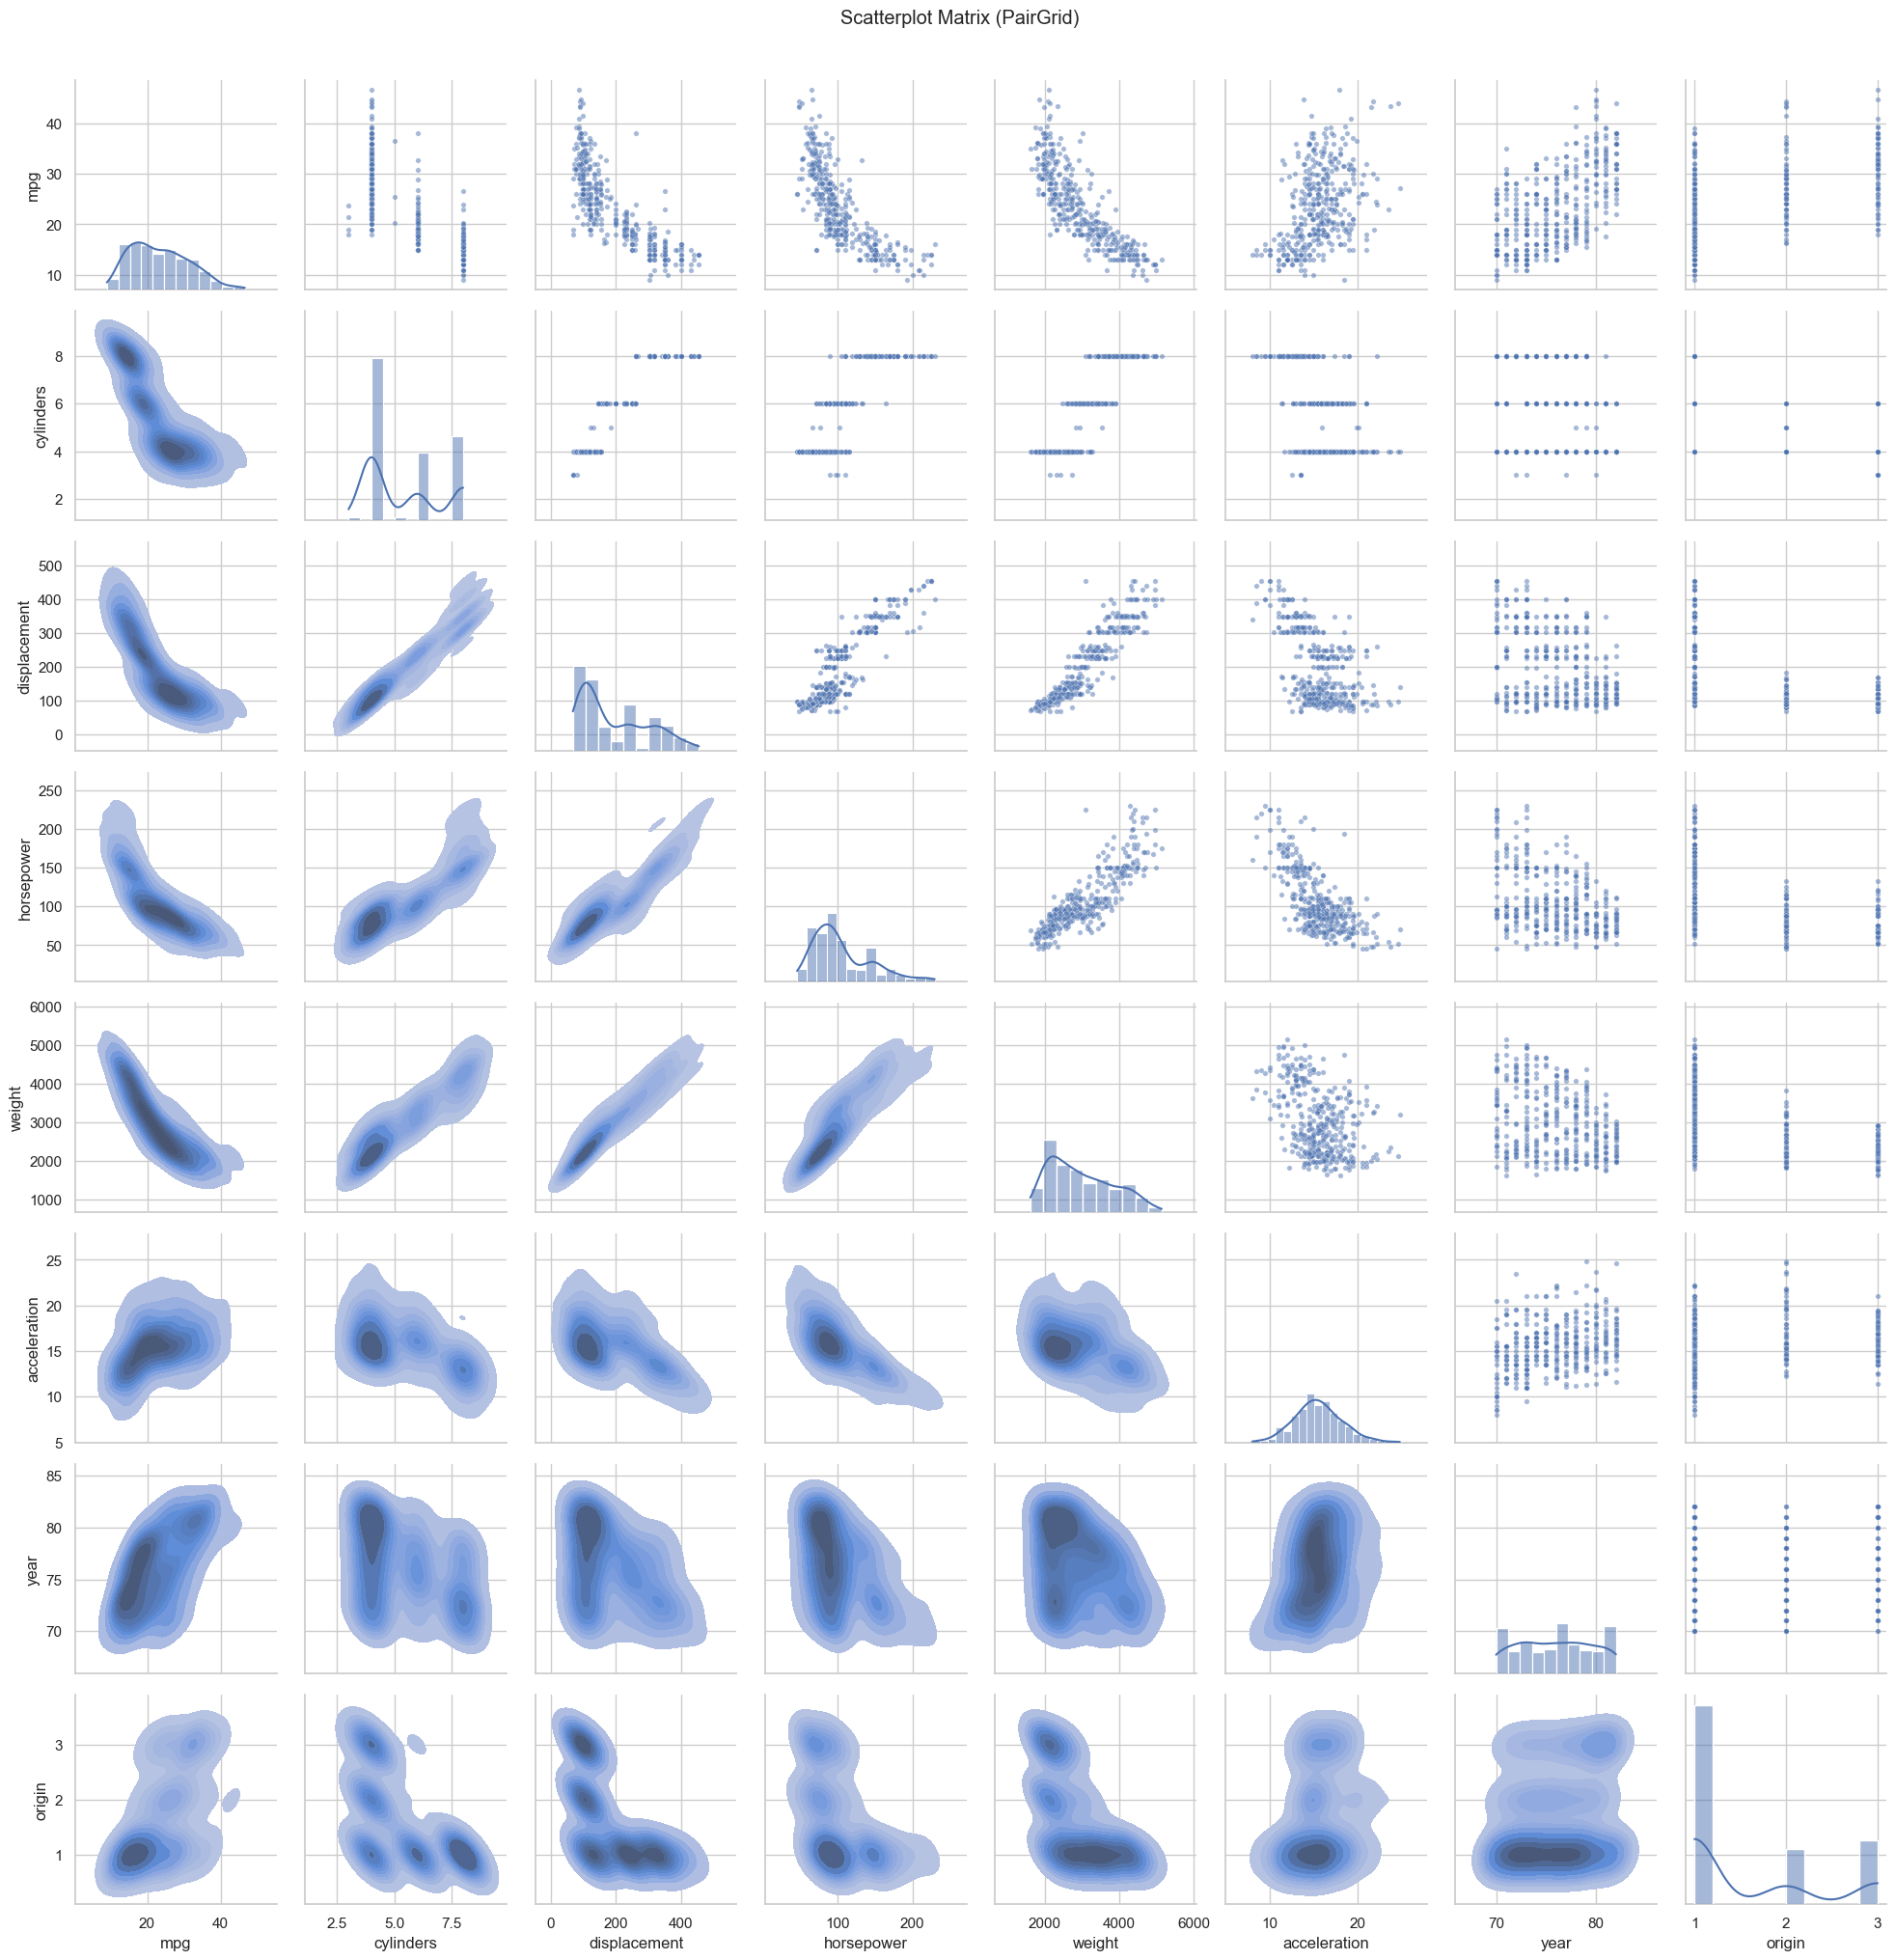

In [53]:
# We want to include all variables. 'name' is categorical, so we'll skip it.
# 'origin' is technically a number (1, 2, 3) but represents categories (USA, Europe, Japan)
# We'll include it, but remember it's a category.

# Select variables for the PairGrid
plot_vars = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']

# Use sns.PairGrid for customization
g = sns.PairGrid(auto_df[plot_vars])
g.map_upper(sns.scatterplot, s=15, alpha=0.5) # Upper triangle: scatter plots
g.map_lower(sns.kdeplot, fill=True)          # Lower triangle: 2D KDE plots (density)
g.map_diag(sns.histplot, kde=True)           # Diagonal: histograms

plt.suptitle('Scatterplot Matrix (PairGrid)', y=1.02)
plt.show()

# 5. Compute the matrix of correlations between the variables using the DataFrame.corr() method. Find a fancy way to display this matrix.

Correlation Matrix:
                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceleration      1.000000  

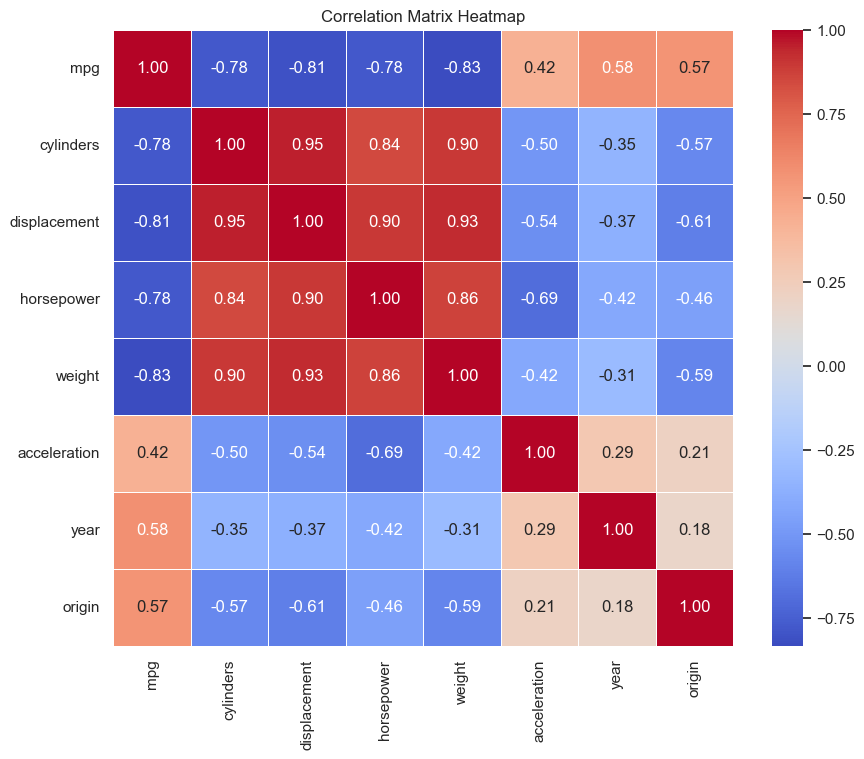

In [54]:
# Compute the correlation matrix (Pearson's)
corr_matrix = auto_df[plot_vars].corr()

print("Correlation Matrix:")
print(corr_matrix)

# A "fancy way to display" is usually a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,     # Show values in the cells
            fmt=".2f",      # Format to 2 decimal places
            cmap='coolwarm',# Color scheme
            linewidths=.5)  # Grid lines
plt.title('Correlation Matrix Heatmap')
plt.show()

# 6. perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results

In [55]:
# 'origin' is a categorical variable (1=USA, 2=Europe, 3=Japan).
# We must treat it as a category using C(origin).
# Statsmodels will automatically create dummy variables.

# Formula for MLR
predictors = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'C(origin)']
formula_mlr = 'mpg ~ ' + ' + '.join(predictors)

print(f"MLR Formula: {formula_mlr}")

mlr_model = smf.ols(formula_mlr, data=auto_df).fit()

# Print the summary
print(mlr_model.summary())

MLR Formula: mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Tue, 21 Oct 2025   Prob (F-statistic):          1.79e-139
Time:                        22:45:56   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

## Is there a relationship between the predictors and the response? Look at the R2 value and the p-values of the coefficients to answer this question.

Yes. The R-squared is 0.821, which is much higher than the 0.605 from the simple model. This model explains 82.1% of the variability in mpg. The Prob (F-statistic) is 2.04e-139 (almost 0), confirming the overall significance of the model.

## Which predictors appear to have a statistically significant relationship to the response? Focus on the p-values associated with each predictor.

We look for P>|t| < 0.05.

Significant predictors: displacement (0.008), weight (0.000), year (0.000), and C(origin) (p-values for T.2 and T.3 are 0.000).

Insignificant predictors: cylinders (0.203), horsepower (0.144), and acceleration (0.369).

Why did horsepower and cylinders become insignificant? Because of multicollinearity (which we saw on the heatmap). They are highly correlated with weight and displacement. The model has essentially "given" all the explanatory power to weight and displacement, making horsepower and cylinders redundant in this specific model.

## What does the coefficient for the year variable suggest? Interpret its sign and magnitude.

The coefficient (coef) for year is 0.7508.

Interpretation: Holding all other predictors (weight, power, etc.) constant, each additional model year (e.g., going from 1975 to 1976) is associated with an increase in fuel efficiency of 0.75 miles per gallon on average. This reflects the general trend of cars becoming more efficient over time.

# 7. Produce a residual plot of the linear regression fit. Comment on any problems you see with the fit. Do your plot suggest any unusually large outliers? In your opinion, which of the MSE, RMSE and MAE would be more convenient to use?

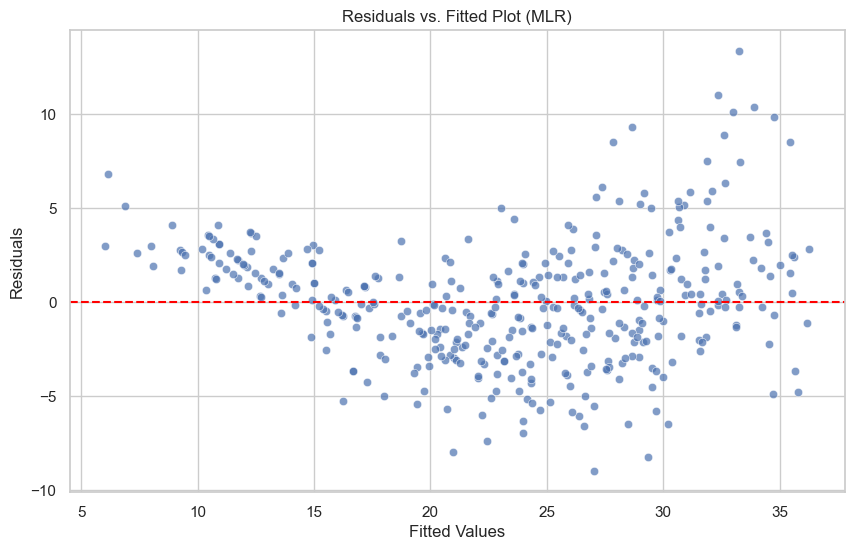

In [56]:
fitted_vals_mlr = mlr_model.fittedvalues
residuals_mlr = mlr_model.resid

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=fitted_vals_mlr, y=residuals_mlr, ax=ax, alpha=0.7)
ax.axhline(0, color='red', linestyle='--')

ax.set_title('Residuals vs. Fitted Plot (MLR)')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
plt.show()

Problems with the fit: This plot looks significantly better than the one for the SLR. The U-shape is almost gone. The residuals are much more randomly scattered around zero, which suggests that the linear model (with multiple predictors) is now a much better fit.
Heteroskedasticity: There are still signs of heteroskedasticity (non-constant variance). The spread (funnel shape) seems slightly larger for high fitted values (on the right) than for low ones.

Outliers: There are a few points with large negative residuals (e.g., below -10). These are cars for which the model predicted high efficiency (e.g., 35 mpg), but they actually had low efficiency (e.g., 20-25 mpg).

MSE vs. RMSE vs. MAE:
MSE ($Mean$ $Squared$ $Error$): $Average$ $of$ $squared$ $errors$. Heavily penalizes large errors (outliers). Inconvenient, as its units are "squared miles per gallon".
RMSE ($Root$ $Mean$ $Squared$ $Error$): $\sqrt{MSE}$. This is the most convenient metric because (a) it is in the same units as mpg (miles per gallon), and (b) it still penalizes large errors, which is usually good.
MAE ($Mean$ $Absolute$ $Error$): $Average$ $of$ $absolute$ $errors$. Also in mpg units, but is more robust to outliers since it doesn't square the errors.
Choice: For this model, I would use RMSE as it's the most common and easily interpreted ("on average, we are off by X miles per gallon"), while still being sensitive to large outliers that are worth noting. If we wanted outliers to have less influence on the metric, we would choose MAE.

# 8. Fit some models with interactions. Do any interactions appear to be statistically significant?

In [57]:
# adding an 'horsepower' * 'weight' interaction.
# The formula 'a * b' in statsmodels automatically includes 'a', 'b', and 'a:b' (the interaction)
# But since 'horsepower' and 'weight' are already in 'formula_mlr',
# we can just add the 'horsepower:weight' term

formula_interact = 'mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin) + horsepower:weight'

interact_model = smf.ols(formula_interact, data=auto_df).fit()

print("\n--- Model with Interaction (horsepower:weight) ---")
print(interact_model.summary())


--- Model with Interaction (horsepower:weight) ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.860
Method:                 Least Squares   F-statistic:                     268.0
Date:                Tue, 21 Oct 2025   Prob (F-statistic):          4.69e-159
Time:                        22:45:57   Log-Likelihood:                -971.22
No. Observations:                 392   AIC:                             1962.
Df Residuals:                     382   BIC:                             2002.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

Is the interaction significant? Yes. Look at the p-value (P>|t|) for horsepower:weight. It is 0.000, which is statistically significant.The $R^2$ also increased to 0.857 (from 0.821).Conclusion: Adding this interaction term improved the model. This means that the effect of horsepower on mpg is not constant — it depends on the weight of the car.

# 9. Try a few different transformations of the variables, such as log(X), √X,X2. Comment on your findings.


--- Model with Quadratic Transformation (horsepower^2) ---
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     428.0
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           5.40e-99
Time:                        22:45:57   Log-Likelihood:                -1133.2
No. Observations:                 392   AIC:                             2272.
Df Residuals:                     389   BIC:                             2284.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------

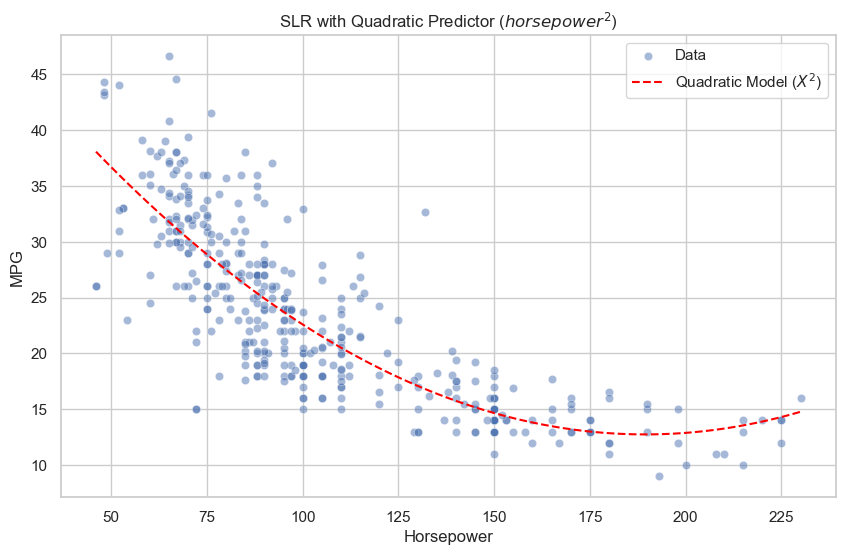

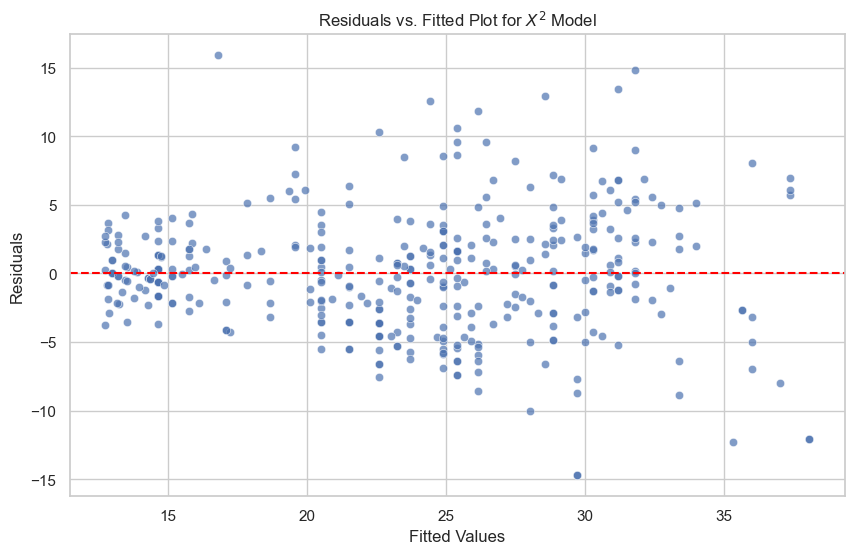

In [58]:
#  build the model we discussed in point 3: mpg ~ horsepower + horsepower^2
# We use I() to perform mathematical operations inside the formula

formula_quad = 'mpg ~ horsepower + I(horsepower**2)'
quad_model = smf.ols(formula_quad, data=auto_df).fit()

print("\n--- Model with Quadratic Transformation (horsepower^2) ---")
print(quad_model.summary())

# ---  plot this model ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x='horsepower', y='mpg', data=auto_df, alpha=0.5, label='Data')

# Generate predictions for a smooth curve
# Create 100 points in the horsepower range
hp_range = pd.DataFrame({'horsepower': np.linspace(auto_df['horsepower'].min(), 
                                                   auto_df['horsepower'].max(), 
                                                   100)})
# Predict mpg for these points
mpg_pred_quad = quad_model.predict(hp_range)

plt.plot(hp_range['horsepower'], mpg_pred_quad, color='red', linestyle='--', 
         label='Quadratic Model ($X^2$)')
plt.title('SLR with Quadratic Predictor ($horsepower^2$)')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.show()

# --- look at the residuals of this new model ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=quad_model.fittedvalues, y=quad_model.resid, ax=ax, alpha=0.7)
ax.axhline(0, color='red', linestyle='--')
ax.set_title('Residuals vs. Fitted Plot for $X^2$ Model')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
plt.show()